# Online Retail II: แบ่งกลุ่มลูกค้าด้วย RFM
เราจะดูว่าใครซื้อ **ล่าสุด**, **บ่อย**, และ **ใช้เงินมาก** จากข้อมูลการซื้อจริง งานนี้เป็นการแบ่งกลุ่มด้วยกติกา ไม่ใช่โมเดลทำนาย

ข้อมูล: [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

In [22]:
import numpy as np
import pandas as pd
from pathlib import Path

file = Path(
    "/kaggle/input/datasets/punkharb/online-retail-ii/online_retail_II.xlsx"
)
assert file.exists(), f"ไม่เจอไฟล์: {file}"

# อ่านทั้งสองชีต แล้วรวมเป็นตารางเดียว
sheets = pd.read_excel(file, sheet_name=None)
raw = pd.concat(sheets.values(), ignore_index=True)

for name, part in sheets.items():
    print(name, part.shape)

print("รวม:", raw.shape)
display(raw.head())

Year 2009-2010 (525461, 8)
Year 2010-2011 (541910, 8)
รวม: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1. สำรวจคุณภาพข้อมูล
เช็กชนิดข้อมูล ค่าว่าง แถวซ้ำ และค่าที่อาจเป็นการคืนสินค้า ก่อนตัดสินใจลบอะไร

In [23]:
# 1) ชนิดข้อมูล, missing, ช่องข้อความว่าง, จำนวนค่าที่ต่างกัน
text_cols = raw.select_dtypes(include=["object", "string"]).columns
blank_text = pd.Series({
    col: raw[col].astype("string").str.strip().eq("").sum()
    for col in text_cols
})

audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique": raw.nunique(dropna=True),
})
audit["blank_text"] = blank_text.reindex(audit.index, fill_value=0).astype(int)

print("Shape:", raw.shape)
display(audit)

# 2) แถวซ้ำและค่าที่ควรตรวจต่อ
invoice = raw["Invoice"].astype("string").str.strip()
quantity = pd.to_numeric(raw["Quantity"], errors="coerce")
price = pd.to_numeric(raw["Price"], errors="coerce")
dates = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
cancelled = invoice.str.upper().str.startswith("C", na=False)

checks = pd.Series({
    "exact_duplicate_rows": raw.duplicated().sum(),
    "invalid_dates": dates.isna().sum(),
    "quantity_negative": quantity.lt(0).sum(),
    "quantity_zero": quantity.eq(0).sum(),
    "price_negative": price.lt(0).sum(),
    "price_zero": price.eq(0).sum(),
    "cancelled_invoice_C": cancelled.sum(),
    "missing_customer_id": raw["Customer ID"].isna().sum(),
})
display(checks.to_frame("rows"))

print("Date range:", dates.min(), "ถึง", dates.max())
display(raw[["Quantity", "Price"]].describe(percentiles=[0.01, 0.5, 0.99]).T)

# ดูตัวอย่าง ไม่ใช่ลบ
display(raw.loc[raw.duplicated(keep=False)].head(10))
display(raw.loc[quantity.lt(0) | price.le(0) | cancelled].head(10))

Shape: (1067371, 8)


,dtype,missing,unique,blank_text
Invoice,object,0,53628,0
StockCode,object,0,5305,0
Description,object,4382,5698,0
Quantity,int64,0,1057,0
InvoiceDate,datetime64[ns],0,47635,0
Price,float64,0,2807,0
Customer ID,float64,243007,5942,0
Country,object,0,43,0


,rows
exact_duplicate_rows,34335
invalid_dates,0
quantity_negative,22950
quantity_zero,0
price_negative,5
price_zero,6202
cancelled_invoice_C,19494
missing_customer_id,243007


Date range: 2009-12-01 07:45:00 ถึง 2011-12-09 12:50:00


,count,mean,std,min,1%,50%,99%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,-3.00,3.0,100.0,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,0.21,2.1,18.0,38970.0


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


## 2. เช็กข้อมูลที่ซ้ำระหว่างสองชีต
สองชีตมีช่วงวันที่ทับกัน จึงต้องตรวจว่าเป็นรายการเดียวกันจริงหรือไม่ก่อนรวม

In [24]:
within_sheet_duplicates = 0

for name, part in sheets.items():
    duplicate_count = part.duplicated().sum()
    within_sheet_duplicates += duplicate_count
    print(
        name,
        "| วันที่:", part["InvoiceDate"].min(), "ถึง", part["InvoiceDate"].max(),
        "| แถวซ้ำในชีต:", duplicate_count
    )

print("แถวซ้ำที่เพิ่มขึ้นหลังรวมชีต:",
      raw.duplicated().sum() - within_sheet_duplicates)

is_cancelled = (
    raw["Invoice"].astype("string").str.upper().str.startswith("C", na=False)
)
display(pd.crosstab(
    is_cancelled,
    raw["Quantity"] < 0,
    rownames=["Invoice ขึ้นต้น C"],
    colnames=["Quantity ติดลบ"],
    margins=True
))

Year 2009-2010 | วันที่: 2009-12-01 07:45:00 ถึง 2010-12-09 20:01:00 | แถวซ้ำในชีต: 6865
Year 2010-2011 | วันที่: 2010-12-01 08:26:00 ถึง 2011-12-09 12:50:00 | แถวซ้ำในชีต: 5268
แถวซ้ำที่เพิ่มขึ้นหลังรวมชีต: 22202


Quantity ติดลบ,False,True,All
Invoice ขึ้นต้น C,,,
False,1044420,3457,1047877
True,1,19493,19494
All,1044421,22950,1067371


In [25]:
first = sheets["Year 2009-2010"]
second = sheets["Year 2010-2011"]

start = pd.Timestamp("2010-12-01")
end = pd.Timestamp("2010-12-10")
cols = first.columns.tolist()

a = first.loc[
    first["InvoiceDate"].between(start, end, inclusive="left"), cols
].drop_duplicates()

b = second.loc[
    second["InvoiceDate"].between(start, end, inclusive="left"), cols
].drop_duplicates()

comparison = a.merge(b, on=cols, how="outer", indicator=True)

print("แถวไม่ซ้ำในช่วงทับกัน — ชีตแรก:", len(a))
print("แถวไม่ซ้ำในช่วงทับกัน — ชีตสอง:", len(b))
display(comparison["_merge"].value_counts())

แถวไม่ซ้ำในช่วงทับกัน — ชีตแรก: 22202
แถวไม่ซ้ำในช่วงทับกัน — ชีตสอง: 22202


_merge
both          22202
left_only         0
right_only        0
Name: count, dtype: int64

## 3. รวมข้อมูลและกันช่วงอนาคตไว้
ใช้ชีตแรกเฉพาะก่อน 1 ธ.ค. 2010 แล้วต่อด้วยชีตที่สอง เพื่อไม่ให้นับช่วงทับกันสองครั้ง จากนั้นแยกข้อมูลตั้งแต่ 1 ก.ย. 2011 ไว้ต่างหาก งาน RFM ด้านล่างใช้เฉพาะอดีต

In [26]:
# เก็บ raw เดิมไว้ ไม่แก้ทับ
first_period = sheets["Year 2009-2010"].loc[
    sheets["Year 2009-2010"]["InvoiceDate"] < "2010-12-01"
]

transactions = pd.concat(
    [first_period, sheets["Year 2010-2011"]],
    ignore_index=True
)

# ใช้ข้อมูลก่อน ก.ย. 2011 สร้างกลุ่มลูกค้า
# กันช่วง ก.ย.–ธ.ค. 2011 ไว้ดูพฤติกรรมหลังจากนั้น
cutoff = pd.Timestamp("2011-09-01")
train_raw = transactions.loc[transactions["InvoiceDate"] < cutoff].copy()
future_raw = transactions.loc[transactions["InvoiceDate"] >= cutoff].copy()

print("แถวที่ตัดเพราะช่วงสองชีตทับกัน:", len(raw) - len(transactions))
print("แถวซ้ำที่ยังเหลือให้ตรวจ:", transactions.duplicated().sum())
print("Train:", train_raw.shape, train_raw["InvoiceDate"].min(),
      "ถึง", train_raw["InvoiceDate"].max())
print("Future holdout:", future_raw.shape, future_raw["InvoiceDate"].min(),
      "ถึง", future_raw["InvoiceDate"].max())

assert train_raw["InvoiceDate"].max() < future_raw["InvoiceDate"].min()

แถวที่ตัดเพราะช่วงสองชีตทับกัน: 22523
แถวซ้ำที่ยังเหลือให้ตรวจ: 11812
Train: (823643, 8) 2009-12-01 07:45:00 ถึง 2011-08-31 17:45:00
Future holdout: (221205, 8) 2011-09-01 08:25:00 ถึง 2011-12-09 12:50:00


## 4. ทำตารางรายการซื้อ
เก็บข้อมูลต้นฉบับไว้ และสร้างตารางสำหรับวิเคราะห์ลูกค้าโดยตัดแถวที่ไม่มี Customer ID, ใบยกเลิก/คืนสินค้า, Quantity หรือ Price ที่ไม่เป็นบวก และแถวซ้ำทุกคอลัมน์ เรา **ไม่ลบ Description ที่ว่าง** เพราะไม่จำเป็นต่อ RFM

ยอดเงินที่จะได้คือยอดซื้อบวก ไม่ใช่รายได้สุทธิ การลบแถวซ้ำเป็นสมมติฐาน เพราะบางแถวที่เหมือนกันทุกช่องอาจเป็นรายการซื้อจริง

In [28]:
train_clean = train_raw.copy()

# ตัดแถวซ้ำกันทุกคอลัมน์
train_clean = train_clean.drop_duplicates()

# เก็บเฉพาะรายการซื้อที่รู้ว่าเป็นลูกค้าคนไหน
train_clean = train_clean[train_clean["Customer ID"].notna()]

# ตัดใบยกเลิก และรายการที่ไม่ใช่ยอดซื้อจริง
train_clean = train_clean[
    ~train_clean["Invoice"].astype(str).str.startswith("C")
    & (train_clean["Quantity"] > 0)
    & (train_clean["Price"] > 0)
].copy()

print("ก่อน clean:", len(train_raw))
print("หลัง clean:", len(train_clean))
print("แถวที่ตัดออก:", len(train_raw) - len(train_clean))

assert train_clean["Customer ID"].notna().all()
assert (train_clean["Quantity"] > 0).all()
assert (train_clean["Price"] > 0).all()
assert not train_clean.duplicated().any()

ก่อน clean: 823643
หลัง clean: 610768
แถวที่ตัดออก: 212875


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
823626,565067,22644,CERAMIC CHERRY CAKE MONEY BANK,2,2011-08-31 17:16:00,1.45,15856.0,United Kingdom
823627,565067,22645,CERAMIC HEART FAIRY CAKE MONEY BANK,2,2011-08-31 17:16:00,1.45,15856.0,United Kingdom
823628,565067,22637,PIGGY BANK RETROSPOT,2,2011-08-31 17:16:00,2.55,15856.0,United Kingdom
823629,565067,22646,CERAMIC STRAWBERRY CAKE MONEY BANK,2,2011-08-31 17:16:00,1.45,15856.0,United Kingdom


## 5. สรุปข้อมูลระดับลูกค้า
หนึ่งแถวของข้อมูลเดิมคือหนึ่งรายการสินค้า เราคูณ Quantity × Price แล้วรวมตามลูกค้า: วันที่ซื้อล่าสุด, จำนวน Invoice ไม่ซ้ำ, และยอดซื้อรวม

In [31]:
purchases = train_clean.copy()
purchases["line_total"] = purchases["Quantity"] * purchases["Price"]

customer_summary = (
    purchases.groupby("Customer ID", as_index=False)
    .agg(
        last_purchase=("InvoiceDate", "max"),
        invoice_count=("Invoice", "nunique"),
        total_spent=("line_total", "sum")
    )
)

display(customer_summary.head())

,Customer ID,last_purchase,invoice_count,total_spent
0,12346.0,2011-01-18 10:01:00,12,77556.46
1,12347.0,2011-08-02 08:48:00,6,3402.39
2,12348.0,2011-04-05 10:47:00,4,1709.40
3,12349.0,2010-10-28 08:23:00,3,2671.14
4,12350.0,2011-02-02 16:01:00,1,334.40


### ตรวจรหัส Invoice ก่อนนับความถี่
บาง Invoice มีรายการสินค้าบันทึกต่างนาที เราตรวจว่าของลูกค้าคนเดิมยังเป็นวันเดียวกัน ก่อนนับ Invoice นั้นเป็นการซื้อครั้งเดียว

In [32]:
print(
    "คู่ลูกค้า–Invoice ที่มีหลายเวลา:",
    purchases.groupby(["Customer ID", "Invoice"])["InvoiceDate"]
    .nunique().gt(1).sum()
)

คู่ลูกค้า–Invoice ที่มีหลายเวลา: 60


In [33]:
reused = (
    purchases.groupby(["Customer ID", "Invoice"])
    .agg(
        first_time=("InvoiceDate", "min"),
        last_time=("InvoiceDate", "max"),
        times=("InvoiceDate", "nunique"),
        rows=("InvoiceDate", "size")
    )
    .query("times > 1")
    .reset_index()
)

print("หลายเวลาแต่ยังเป็นวันเดียวกัน:",
      (reused["first_time"].dt.date == reused["last_time"].dt.date).sum())
print("ข้ามวัน:",
      (reused["first_time"].dt.date != reused["last_time"].dt.date).sum())

display(reused.head(10))

หลายเวลาแต่ยังเป็นวันเดียวกัน: 60
ข้ามวัน: 0


,Customer ID,Invoice,first_time,last_time,times,rows
0,12576.0,521651,2010-09-07 13:41:00,2010-09-07 13:42:00,2,13
1,12631.0,521922,2010-09-09 14:49:00,2010-09-09 14:50:00,2,38
2,12637.0,541631,2011-01-20 10:47:00,2011-01-20 10:48:00,2,72
3,12645.0,520899,2010-09-01 09:25:00,2010-09-01 09:26:00,2,26
4,12668.0,500353,2010-03-07 15:24:00,2010-03-07 15:25:00,2,110
5,12748.0,550320,2011-04-17 12:37:00,2011-04-17 12:38:00,2,83
6,12754.0,543179,2011-02-04 10:31:00,2011-02-04 10:32:00,2,37
7,12835.0,518894,2010-08-12 13:23:00,2010-08-12 13:24:00,2,18
8,12836.0,542806,2011-02-01 11:19:00,2011-02-01 11:20:00,2,39
9,12890.0,533505,2010-11-17 14:05:00,2010-11-17 14:06:00,2,56


## 6. คำนวณ Recency
R คือจำนวนวันจาก **1 ก.ย. 2011** ย้อนกลับไปถึงวันที่ลูกค้าซื้อครั้งล่าสุด ไม่ใช่ระยะห่างระหว่างทุกการซื้อ

In [35]:
reference_date = pd.Timestamp("2011-09-01")

customer_summary["recency_days"] = (
    reference_date - customer_summary["last_purchase"].dt.normalize()
).dt.days

display(customer_summary.head())

,Customer ID,last_purchase,invoice_count,total_spent,recency_days
0,12346.0,2011-01-18 10:01:00,12,77556.46,226
1,12347.0,2011-08-02 08:48:00,6,3402.39,30
2,12348.0,2011-04-05 10:47:00,4,1709.40,149
3,12349.0,2010-10-28 08:23:00,3,2671.14,308
4,12350.0,2011-02-02 16:01:00,1,334.40,211


## 7. ให้คะแนน RFM
ให้คะแนนเทียบกันในกลุ่มลูกค้าที่วิเคราะห์: R ยิ่งน้อยยิ่งดี ส่วน F และ M ยิ่งมากยิ่งดี คะแนน 1–5 เป็นอันดับสัมพัทธ์ ไม่ใช่ยอดเงินจริง

In [36]:
customer_summary["R_score"] = (
    6 - np.ceil(customer_summary["recency_days"].rank(pct=True) * 5)
).astype(int)

customer_summary["F_score"] = (
    np.ceil(customer_summary["invoice_count"].rank(pct=True) * 5)
).astype(int)

customer_summary["M_score"] = (
    np.ceil(customer_summary["total_spent"].rank(pct=True) * 5)
).astype(int)

customer_summary["RFM"] = (
    customer_summary[["R_score", "F_score", "M_score"]]
    .astype(str)
    .agg("".join, axis=1)
)

display(customer_summary.head())

,Customer ID,last_purchase,invoice_count,total_spent,recency_days,R_score,F_score,M_score,RFM
0,12346.0,2011-01-18 10:01:00,12,77556.46,226,3,5,5,355
1,12347.0,2011-08-02 08:48:00,6,3402.39,30,5,4,5,545
2,12348.0,2011-04-05 10:47:00,4,1709.40,149,3,4,4,344
3,12349.0,2010-10-28 08:23:00,3,2671.14,308,2,3,5,235
4,12350.0,2011-02-02 16:01:00,1,334.40,211,3,1,2,312


## 8. จัดกลุ่มด้วยกติกา
ใช้ R/F/M score ตั้งชื่อกลุ่มที่อธิบายได้ เช่น ลูกค้าคุณค่าสูงและลูกค้าเสี่ยงหาย นี่ไม่ใช่ K-Means หรือโมเดลที่เทรนมา

In [37]:
customer_summary["segment"] = np.select(
    [
        (customer_summary["R_score"] >= 4) &
        (customer_summary["F_score"] >= 4) &
        (customer_summary["M_score"] >= 4),

        (customer_summary["R_score"] <= 2) &
        (customer_summary["F_score"] >= 3),

        (customer_summary["R_score"] >= 4) &
        (customer_summary["F_score"] >= 3),

        (customer_summary["R_score"] >= 4) &
        (customer_summary["F_score"] <= 2),
    ],
    [
        "ลูกค้าคุณค่าสูง",
        "ลูกค้าเสี่ยงหาย",
        "ลูกค้าประจำ",
        "เพิ่งซื้อแต่ยังไม่บ่อย",
    ],
    default="กลุ่มอื่น"
)

display(customer_summary["segment"].value_counts())

segment
กลุ่มอื่น                 2578
ลูกค้าคุณค่าสูง           1225
ลูกค้าเสี่ยงหาย            568
เพิ่งซื้อแต่ยังไม่บ่อย     479
ลูกค้าประจำ                399
Name: count, dtype: int64

## 9. ดูขนาดและยอดซื้อของแต่ละกลุ่ม
เปรียบเทียบจำนวนลูกค้าและยอดซื้อของแต่ละกลุ่ม เพื่อเห็นว่ากลุ่มไหนควรให้ความสนใจ

In [38]:
segment_summary = (
    customer_summary.groupby("segment", as_index=False)
    .agg(
        customers=("Customer ID", "nunique"),
        total_spent=("total_spent", "sum"),
        median_orders=("invoice_count", "median"),
        median_recency=("recency_days", "median")
    )
)

segment_summary["customer_pct"] = (
    segment_summary["customers"] / segment_summary["customers"].sum() * 100
).round(1)

segment_summary["spend_pct"] = (
    segment_summary["total_spent"] / segment_summary["total_spent"].sum() * 100
).round(1)

display(segment_summary.sort_values("total_spent", ascending=False))

,segment,customers,total_spent,median_orders,median_recency,customer_pct,spend_pct
1,ลูกค้าคุณค่าสูง,1225,9687793.108,10.0,30.0,23.3,70.6
0,กลุ่มอื่น,2578,2301561.093,1.0,291.0,49.1,16.8
3,ลูกค้าเสี่ยงหาย,568,1081054.292,4.0,311.0,10.8,7.9
2,ลูกค้าประจำ,399,393858.060,3.0,51.0,7.6,2.9
4,เพิ่งซื้อแต่ยังไม่บ่อย,479,250791.013,1.0,46.0,9.1,1.8


## 10. กราฟสรุป
เทียบสัดส่วนลูกค้ากับสัดส่วนยอดซื้อบวก ชื่อกลุ่มบนกราฟใช้ภาษาอังกฤษเพื่อให้แสดงผลได้ใน Kaggle

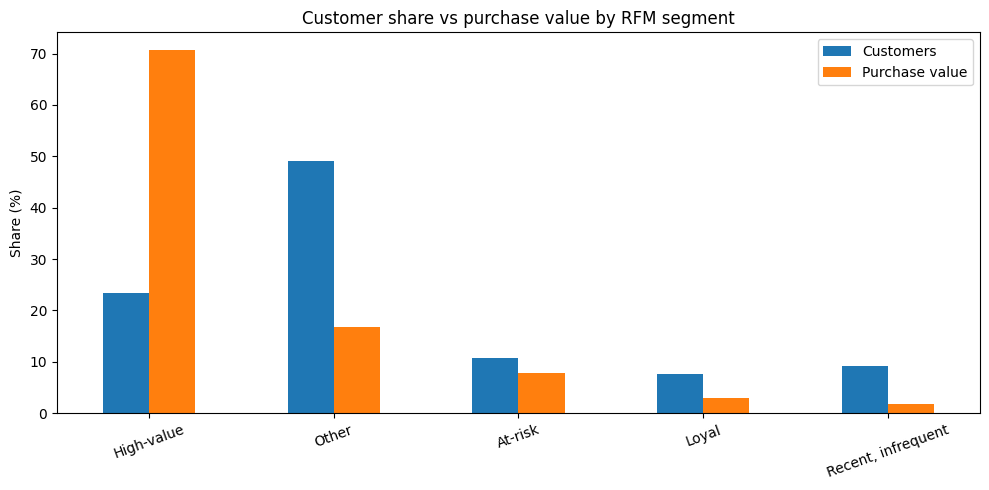

In [39]:
import matplotlib.pyplot as plt

names = {
    "ลูกค้าคุณค่าสูง": "High-value",
    "ลูกค้าเสี่ยงหาย": "At-risk",
    "ลูกค้าประจำ": "Loyal",
    "เพิ่งซื้อแต่ยังไม่บ่อย": "Recent, infrequent",
    "กลุ่มอื่น": "Other",
}

chart = segment_summary.copy()
chart["segment_name"] = chart["segment"].map(names)

ax = (
    chart.sort_values("spend_pct", ascending=False)
    .set_index("segment_name")[["customer_pct", "spend_pct"]]
    .rename(columns={
        "customer_pct": "Customers",
        "spend_pct": "Purchase value"
    })
    .plot.bar(figsize=(10, 5), rot=20)
)

ax.set_title("Customer share vs purchase value by RFM segment")
ax.set_xlabel("")
ax.set_ylabel("Share (%)")
ax.legend(title="")
plt.tight_layout()
plt.show()

ลูกค้ากลุ่ม High-value มีเพียง 23.3% ของลูกค้าทั้งหมด แต่คิดเป็น 70.6% ของยอดซื้อในข้อมูลที่วิเคราะห์ จึงเป็นกลุ่มที่ควรให้ความสำคัญในการรักษาความสัมพันธ์ ส่วนกลุ่ม At-risk มี 568 คนที่เคยซื้อหลายครั้งแต่ไม่ได้กลับมาซื้อเมื่อไม่นานนี้ เหมาะสำหรับพิจารณาแคมเปญติดต่อกลับ

**ข้อจำกัด:** กลุ่ม High-value ถูกกำหนดโดยใช้คะแนนยอดซื้อ (M) อยู่แล้ว กราฟนี้จึงอธิบายสัดส่วนของกลุ่ม ไม่ได้พิสูจน์ผลของแคมเปญ ข้อมูลอนาคตที่กันไว้ยังไม่ได้ใช้ประเมินผล